**Seasonal** **Agriculture** **Performance** **Analysis**

 Major Data Analytics Project

 Domain: Agriculture

 Project Theme: Seasonal Agriculture Performance

 Tools: Python, Pandas, NumPy, Matplotlib, Seaborn

 Project Goal:-  Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data

Important: This is a Data Analytics project. No Machine Learning or dashboard development is required.

1.**Problem** **Statment** :-

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

2. **Project** **Objective** :-

*    Understand the structure and quality of the agricultural dataset.
*   Clean and prepare the data for analysis.
*  Explore seasonal patterns in the dataset.
*    Perform descriptive and statistical analysis.
*  Investigate relationships among relevant variables.
*   Compare agricultural performance across seasons and other meaningful groups.
*  Use appropriate univariate, bivariate and multivariate visualizations.
*   Identify significant findings from the data.




3 **DataSet**

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit, and water usage. It includes 4,000 records and 28 attributes, providing information useful for analyzing crop yield, profitability, and agricultural resource efficiency.

Dataset file: seasonal_agriculture_performance_dataset.csv


In [4]:
## Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

%matplotlib inline

In [5]:
## 1. Load Data
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


**4. Initial** **Data** **Understanding.**

In [6]:
## Dataset Shape
print("Shape:", df.shape[0])
print("Shape:", df.shape[1])

Shape: 4000
Shape: 28


In [7]:
# top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
## Last five rows.
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [9]:
# Random sample of records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,Flood,228.2,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,Drip,65.9,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,Drip,143.0,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,Rainfed,116.4,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,Flood,242.8,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [10]:
# Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [11]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [12]:
# Numerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [13]:
# Categorical summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


**5.** **Data** **Quality** **Analysis**

Before performing analysis, investigate missing values, duplicates, data types and unusual values.

In [14]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean()*100).sort_values(ascending=False)
missing_summary = pd.DataFrame({"Missing_Count":missing,"Missing_Percent":missing_percent.round(2)})
missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


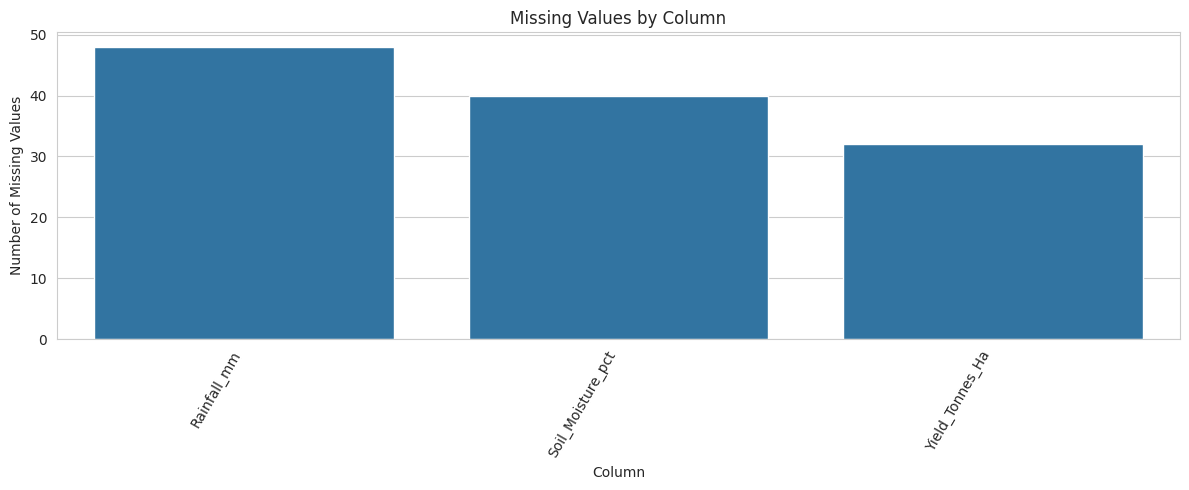

In [15]:
# Visualize missing values
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [16]:
# Dupliate Records
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [17]:
# Remove dupplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (4000, 28)


In [18]:
# Check data type again
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [19]:
# Check unique values for categorical columns
categorical_columns=df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(),"unique Values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique Values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique Values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique Values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique Values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique Values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique Values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [20]:
# Check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


**Missing Value Treatment**

In [21]:
# numerical columns missing value treatment
numerical_columns=df.select_dtypes(include=np.number).columns
for col in numerical_columns:
  if df[col].isnull().sum()>0:
   df[col]=df[col].fillna(df[col].median())

print("Remaining missing values:",df.isnull().sum().sum())

Remaining missing values: 0


**6.** **Features/ Variable** **Review**

In [23]:
# Numerical and Categorical column list
numerical_columns=df.select_dtypes(include=np.number).columns.tolist()
categorical_columns=df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Columns:",numerical_columns)
print("\nCategorical Columns:",categorical_columns)

Numerical Columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical Columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


**7. Descriptive/Statistical Analysis**

In [25]:
# Descriptive statistics

stats = df[numerical_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20,1315.200,460.40000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00,39.000,9.40000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


In [28]:
# Median and standard deviation

statistical_summary =pd.DataFrame({
                    "Mean" : df[numerical_columns].mean(),
                    "Median" : df[numerical_columns].median(),
                    "Std_Dev" : df[numerical_columns].std(),
                    "Min" : df[numerical_columns].min(),
                    "Max" : df[numerical_columns].max()
                })

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.507150,26.4000,6.678837,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


In [31]:
# Seasonal descriptive summary
season_summary =df.groupby("Season")[numerical_columns].agg(["mean" , "median" , "std"])
season_summary

Farm_Area_Hectares                  Rainfall_mm                     \
                     mean median       std        mean median         std   
Season                                                                      
Kharif           7.944924  8.180  4.282328  849.199663  853.1  183.686045   
Rabi             7.752207  7.680  4.179402  437.615366  432.2  175.351345   
Zaid             8.091246  8.085  4.162594  304.654714  288.2  157.238490   

       Avg_Temperature_C                  Humidity_pct                   \
                    mean median       std         mean median       std   
Season                                                                    
Kharif         28.454019   28.5  2.510166    71.812591  71.90  8.861902   
Rabi           23.489183   23.5  2.459561    57.893178  58.10  9.001575   
Zaid           31.042088   31.0  2.554911    52.012121  52.35  9.051898   

       Sunlight_Hours_Day                    Soil_pH                   \
                     mean median       std      mean median       std   
Season                                                                  
Kharif           6.793367    6.8  0.977077  6.727993  6.730  0.642986   
Rabi             7.589797    7.6  1.001779  6.673749  6.670  0.638481   
Zaid             8.178788    8.2  1.045260  6.694865  6.655  0.642794   

       Soil_Moisture_pct                  Nitrogen_kg_ha                     \
                    mean median       std           mean  median        std   
Season                                                                        
Kharif         31.149859   31.1  5.040674     120.020124  119.80  31.176322   
Rabi           24.069392   24.0  4.940544     120.402827  120.30  31.098788   
Zaid           19.279630   19.1  4.940507     120.525421  120.15  31.702789   

       Phosphorus_kg_ha                   Potassium_kg_ha                    \
                   mean median        std            mean median        std   
Season                                                                        
Kharif        58.096515  57.40  17.154119      105.303485  104.8  27.033286   
Rabi          57.311002  57.70  17.119842      103.926060  104.8  28.868968   
Zaid          58.129125  57.45  16.291470      105.416835  106.3  26.658984   

       Fertilizer_kg_ha                    Pesticide_Litre_ha         \
                   mean  median        std               mean median   
Season                                                                 
Kharif       187.077965  188.20  60.819319           5.079747  5.180   
Rabi         185.407068  185.30  59.950613           5.024690  5.020   
Zaid         184.638047  183.95  59.469455           5.171212  5.185   

                 Seed_Quality_Score                  Yield_Tonnes_Ha         \
             std               mean median       std            mean median   
Season                                                                        
Kharif  1.959252           0.821613   0.82  0.101423        5.628612   1.94   
Rabi    1.994465           0.832170   0.84  0.101561        5.039435   1.67   
Zaid    1.993728           0.823165   0.83  0.102560        4.641313   1.46   

                  Production_Tonnes                    Market_Price_INR_Tonne  \
              std              mean median         std                   mean   
Season                                                                          
Kharif  14.392742         46.311192  13.24  135.704677           44850.906127   
Rabi    12.751545         41.486712  11.08  121.904792           44747.974800   
Zaid    11.273088         38.886111   9.97  112.000668           44212.033670   

                              Total_Cost_INR                           \
         median           std           mean    median            std   
Season                                                                  
Kharif  25793.0  30301.557639  531804.408094  524840.0  298487.687038   
Rabi    26041.0  

## 8. Outliers Investigated

Outliers are checked using the **IQR method** on key numeric performance columns. Extreme values are largely driven by **Sugarcane**, whose per-hectare yield and profit figures are naturally an order of magnitude higher than other crops — these are kept in the analysis (they are real, not data-entry errors) but flagged, since they can pull group averages upward.



In [36]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

outlier_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Rainfall_mm']
for col in outlier_cols:
    n, low, high = count_outliers_iqr(df[col])
    print(f"{col:35s} -> {n:4d} outliers  (normal range: {low:,.1f} to {high:,.1f})")


Yield_Tonnes_Ha                     ->  302 outliers  (normal range: -1.6 to 5.5)
Profit_INR                          ->  404 outliers  (normal range: -696,111.0 to 763,567.0)
Water_Efficiency_t_per_1000m3       ->  322 outliers  (normal range: -3.6 to 10.4)
Rainfall_mm                         ->    0 outliers  (normal range: -319.0 to 1,522.6)


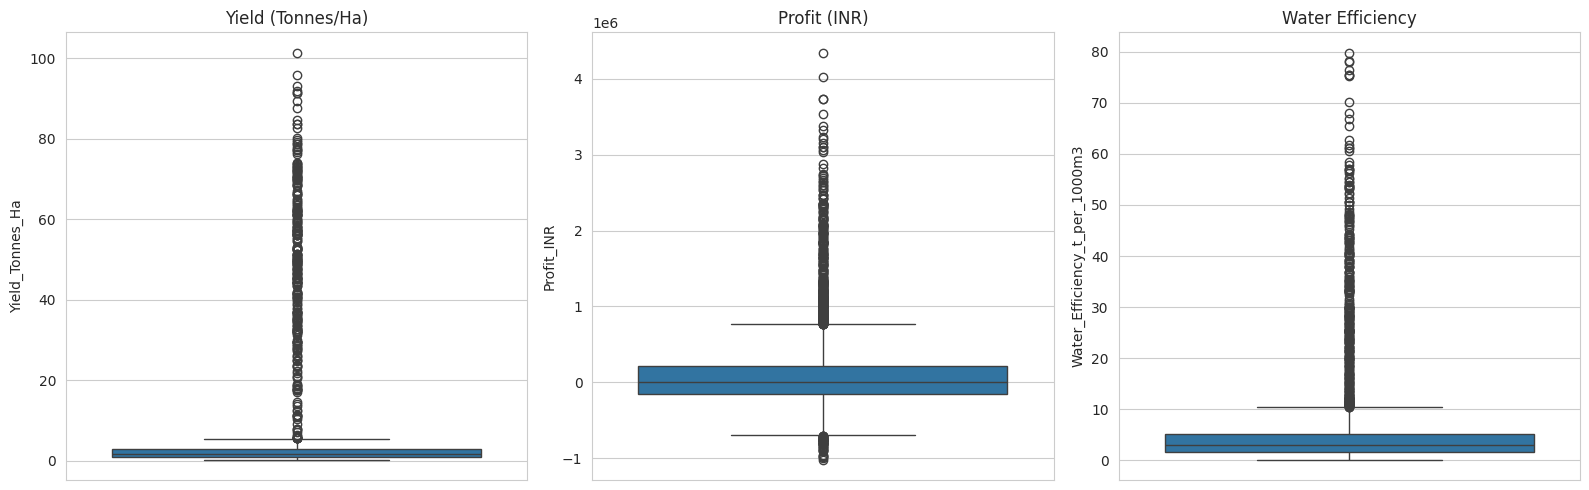

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0]).set_title('Yield (Tonnes/Ha)')
sns.boxplot(y=df['Profit_INR'], ax=axes[1]).set_title('Profit (INR)')
sns.boxplot(y=df['Water_Efficiency_t_per_1000m3'], ax=axes[2]).set_title('Water Efficiency')
plt.tight_layout()
plt.show()


In [38]:
print("Mean yield by crop (sorted):")
print(df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False))

Mean yield by crop (sorted):
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


## 9. Univariate Analysis
Distribution of individual variables: season/crop/irrigation counts and the spread of yield and profit.

/tmp/ipykernel_1265/2701748115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Season', data=df, order=df['Season'].value_counts().index, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_1265/2701748115.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Crop', data=df, order=df['Crop'].value_counts().index, ax=axes[0,1], palette='crest')
/tmp/ipykernel_1265/2701748115.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Irrigation_Method', data=df, order=df['Irrigation_Method'].value_counts().index, ax=axes[1,0], palette='f

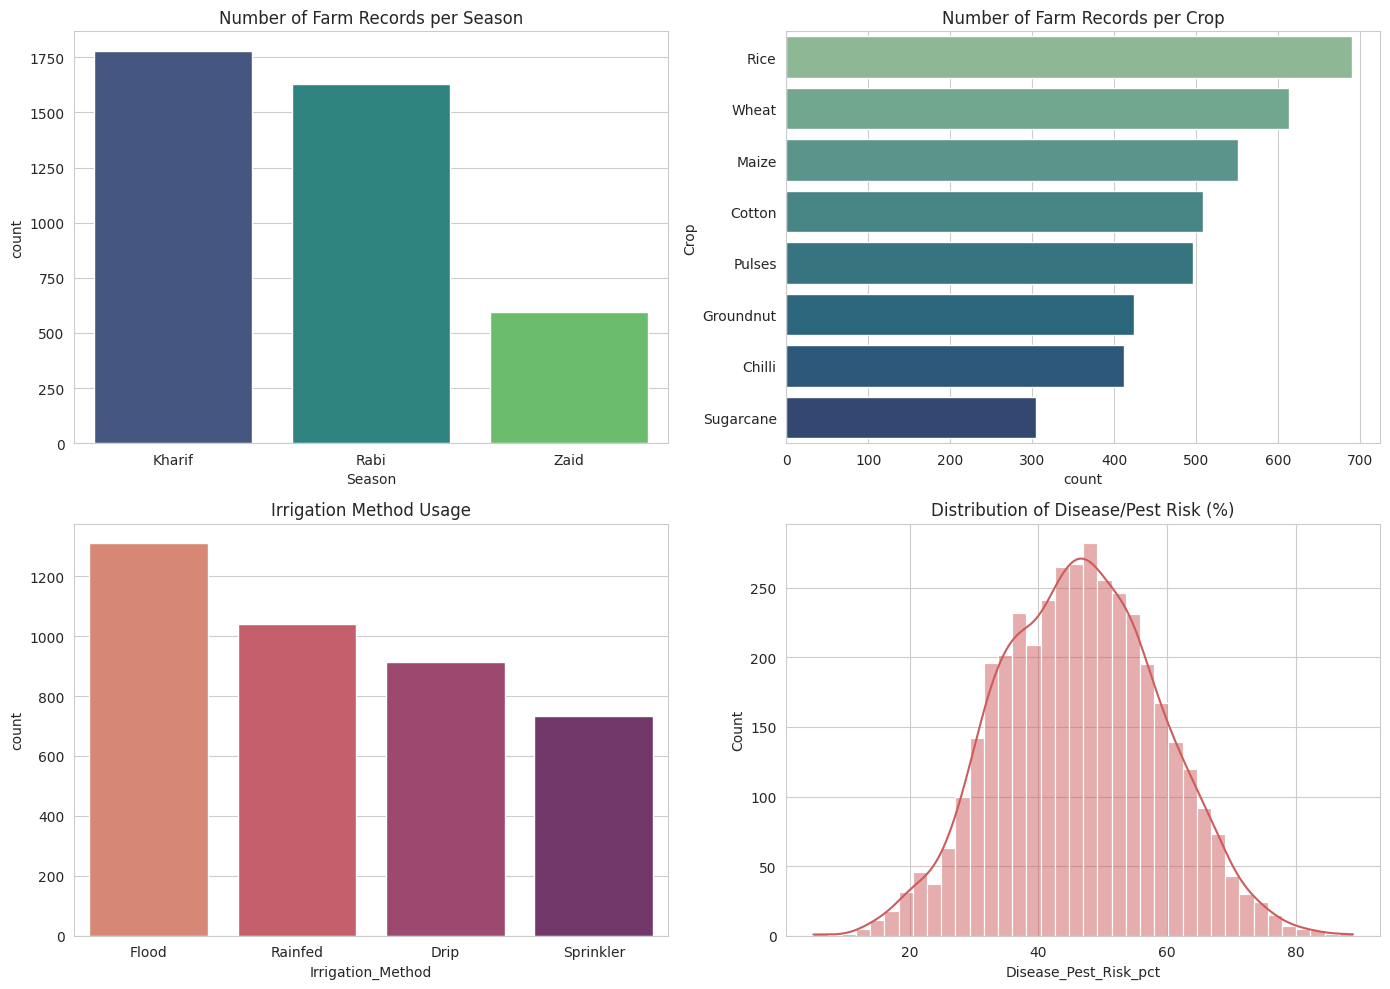

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='Season', data=df, order=df['Season'].value_counts().index, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Number of Farm Records per Season')

sns.countplot(y='Crop', data=df, order=df['Crop'].value_counts().index, ax=axes[0,1], palette='crest')
axes[0,1].set_title('Number of Farm Records per Crop')

sns.countplot(x='Irrigation_Method', data=df, order=df['Irrigation_Method'].value_counts().index, ax=axes[1,0], palette='flare')
axes[1,0].set_title('Irrigation Method Usage')

sns.histplot(df['Disease_Pest_Risk_pct'], kde=True, ax=axes[1,1], color='indianred')
axes[1,1].set_title('Distribution of Disease/Pest Risk (%)')

plt.tight_layout()
plt.show()


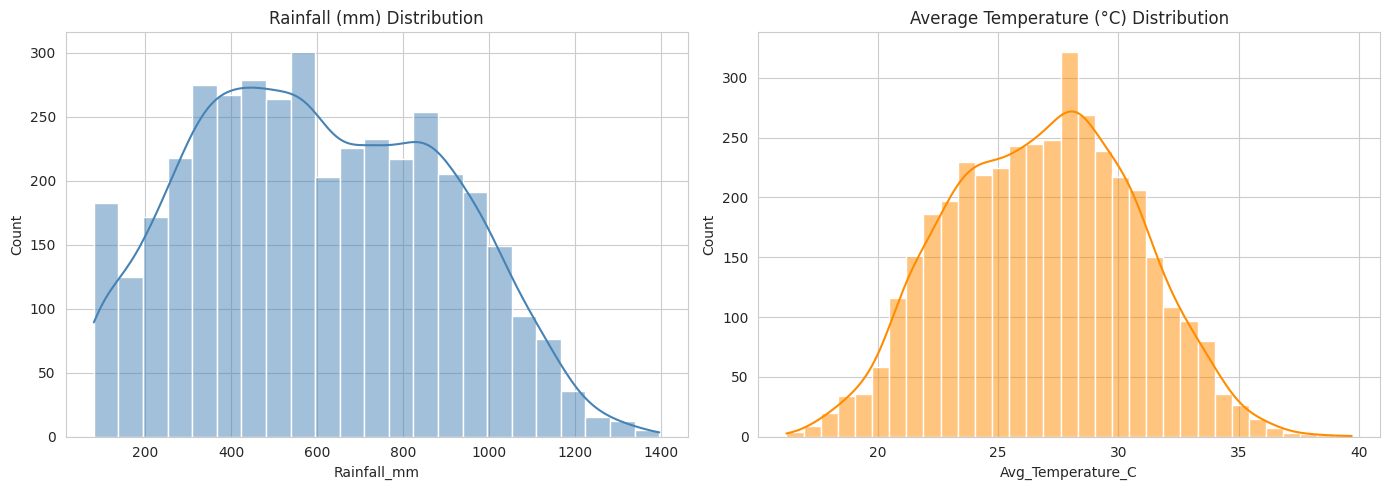

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Rainfall_mm'], kde=True, ax=axes[0], color='steelblue').set_title('Rainfall (mm) Distribution')
sns.histplot(df['Avg_Temperature_C'], kde=True, ax=axes[1], color='darkorange').set_title('Average Temperature (°C) Distribution')
plt.tight_layout()
plt.show()


## 10. Bivariate Analysis

Examining the relationship between **two** variables at a time:
Rainfall vs Yield (do wetter farms yield more?) and Irrigation Method vs
Profit (does irrigation choice affect profitability?).

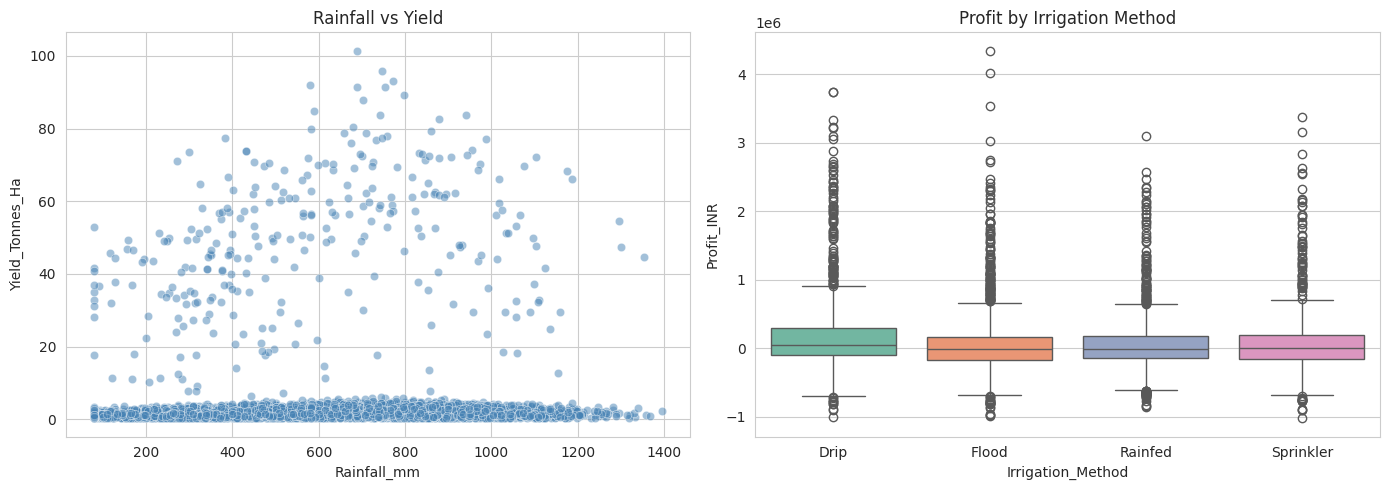

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha",
                 alpha=0.5, color="steelblue", ax=axes[0])
axes[0].set_title("Rainfall vs Yield")

sns.boxplot(data=df, x="Irrigation_Method", y="Profit_INR",
            hue="Irrigation_Method", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Profit by Irrigation Method")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1265/930252317.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_1265/930252317.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Profit_INR', data=df, ax=axes[1], palette='Set2')


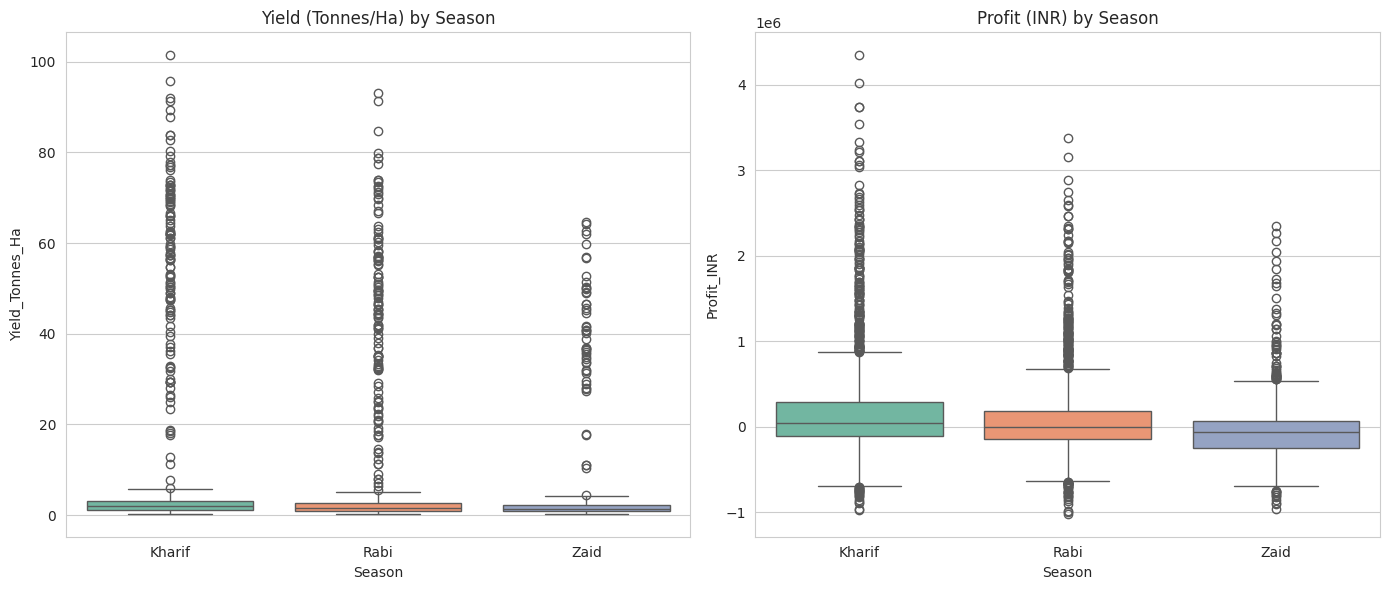

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Yield (Tonnes/Ha) by Season')
sns.boxplot(x='Season', y='Profit_INR', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Profit (INR) by Season')
plt.tight_layout()
plt.show()


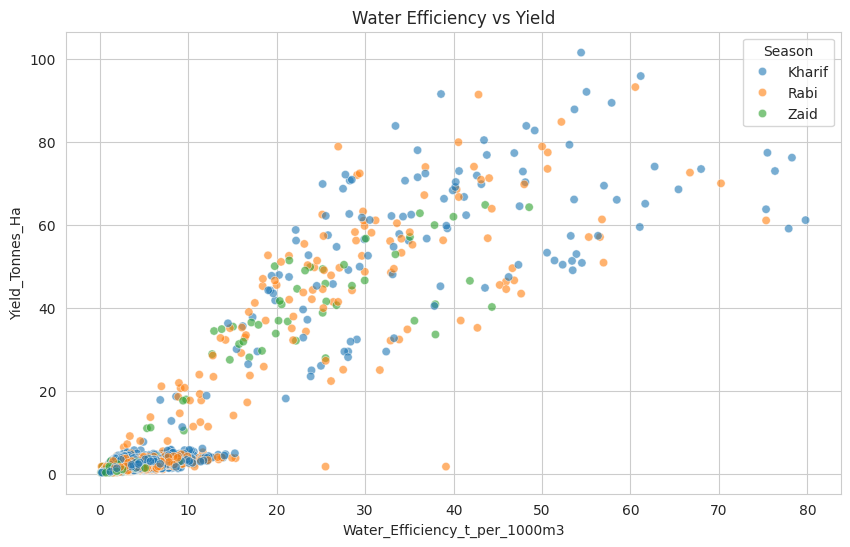

Correlation (Water Efficiency vs Yield): 0.913


In [48]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Water_Efficiency_t_per_1000m3', y='Yield_Tonnes_Ha', data=df, hue='Season', alpha=0.6)
plt.title('Water Efficiency vs Yield')
plt.show()

print("Correlation (Water Efficiency vs Yield):", round(df['Water_Efficiency_t_per_1000m3'].corr(df['Yield_Tonnes_Ha']), 3))


## 11. Multivariate Analysis
Bringing in three or more variables together: Yield vs Rainfall, colored
by Crop and sized conceptually by Season via faceting — this shows how
the rainfall-yield relationship shifts across both crop type and season
at once.

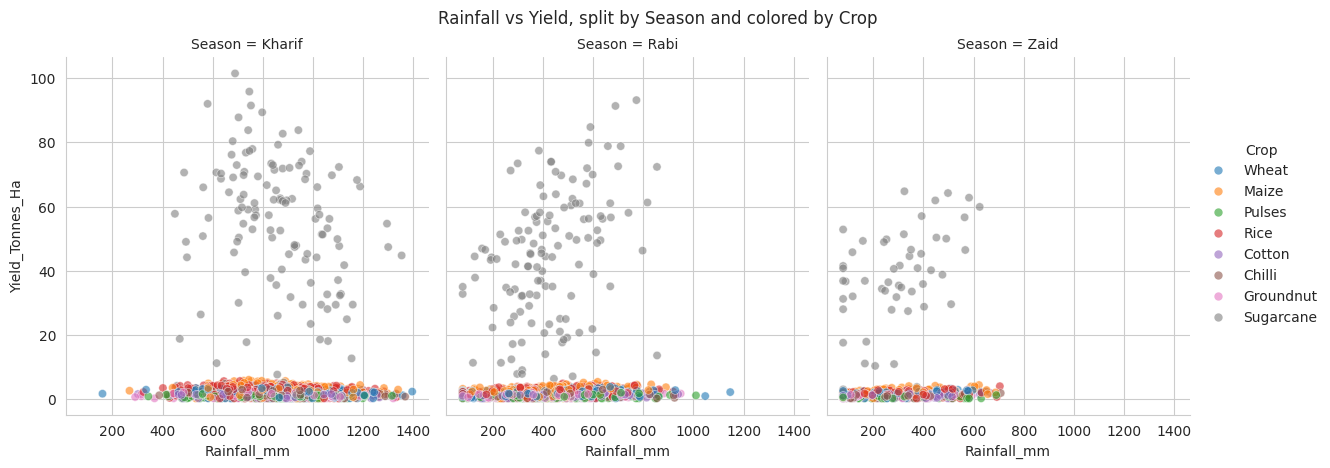

In [50]:
g = sns.relplot(
    data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha",
    hue="Crop", col="Season", kind="scatter",
    alpha=0.6, height=4.5, aspect=0.9
)
g.fig.suptitle("Rainfall vs Yield, split by Season and colored by Crop", y=1.03)
plt.show()

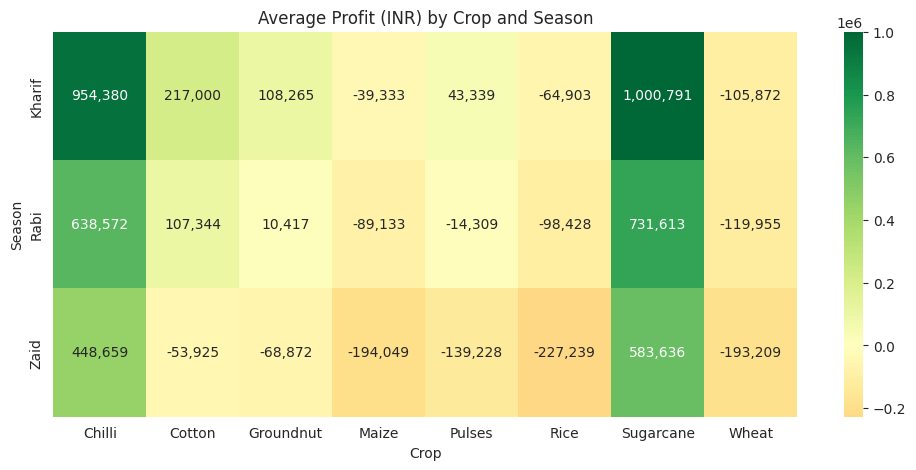

In [51]:
crop_season_profit = df.groupby(['Season', 'Crop'])['Profit_INR'].mean().unstack()
plt.figure(figsize=(12, 5))
sns.heatmap(crop_season_profit, annot=True, fmt=',.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.show()


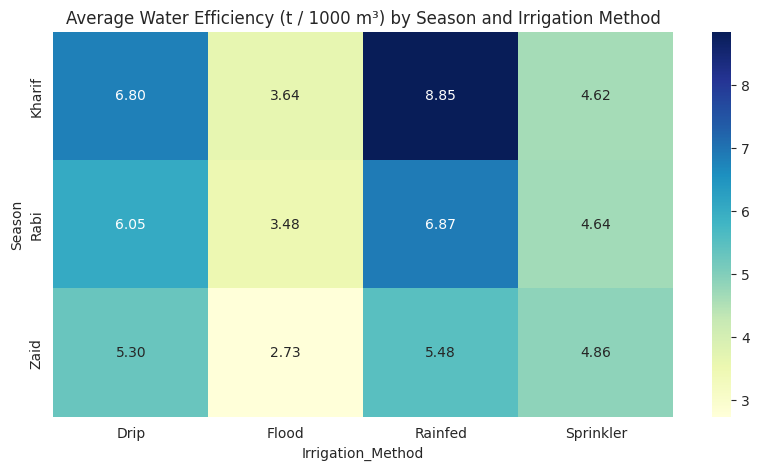

In [52]:
season_irrigation_eff = df.groupby(['Season', 'Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().unstack()
plt.figure(figsize=(10, 5))
sns.heatmap(season_irrigation_eff, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Water Efficiency (t / 1000 m³) by Season and Irrigation Method')
plt.show()

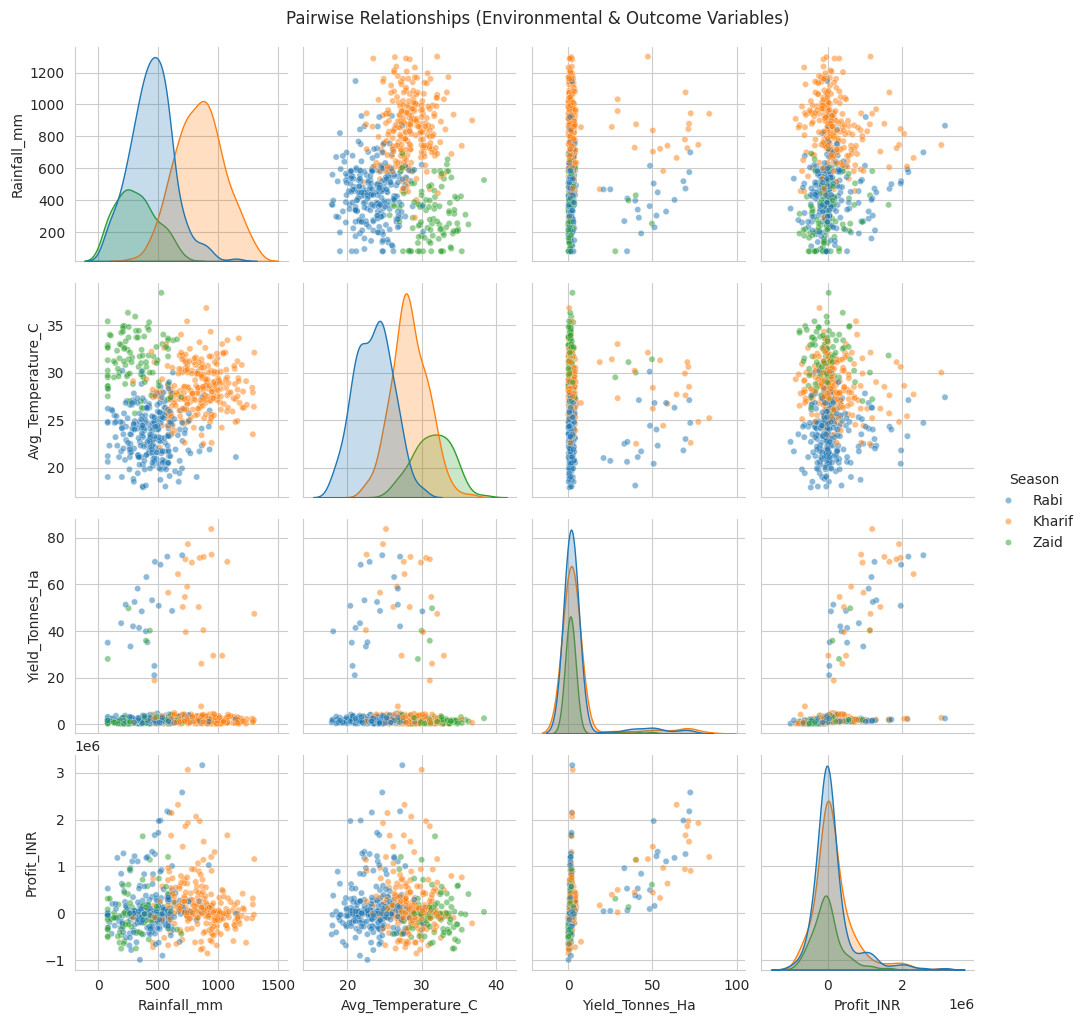

In [53]:
fig = sns.pairplot(
    df[['Rainfall_mm', 'Avg_Temperature_C', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']].sample(600, random_state=42),
    hue='Season', diag_kind='kde', plot_kws={'alpha':0.5, 's':20}
)
plt.suptitle('Pairwise Relationships (Environmental & Outcome Variables)', y=1.02)
plt.show()


## 12. Correlation Analysis
A correlation heatmap across all numeric columns, plus the strongest
positive and negative correlations printed explicitly.

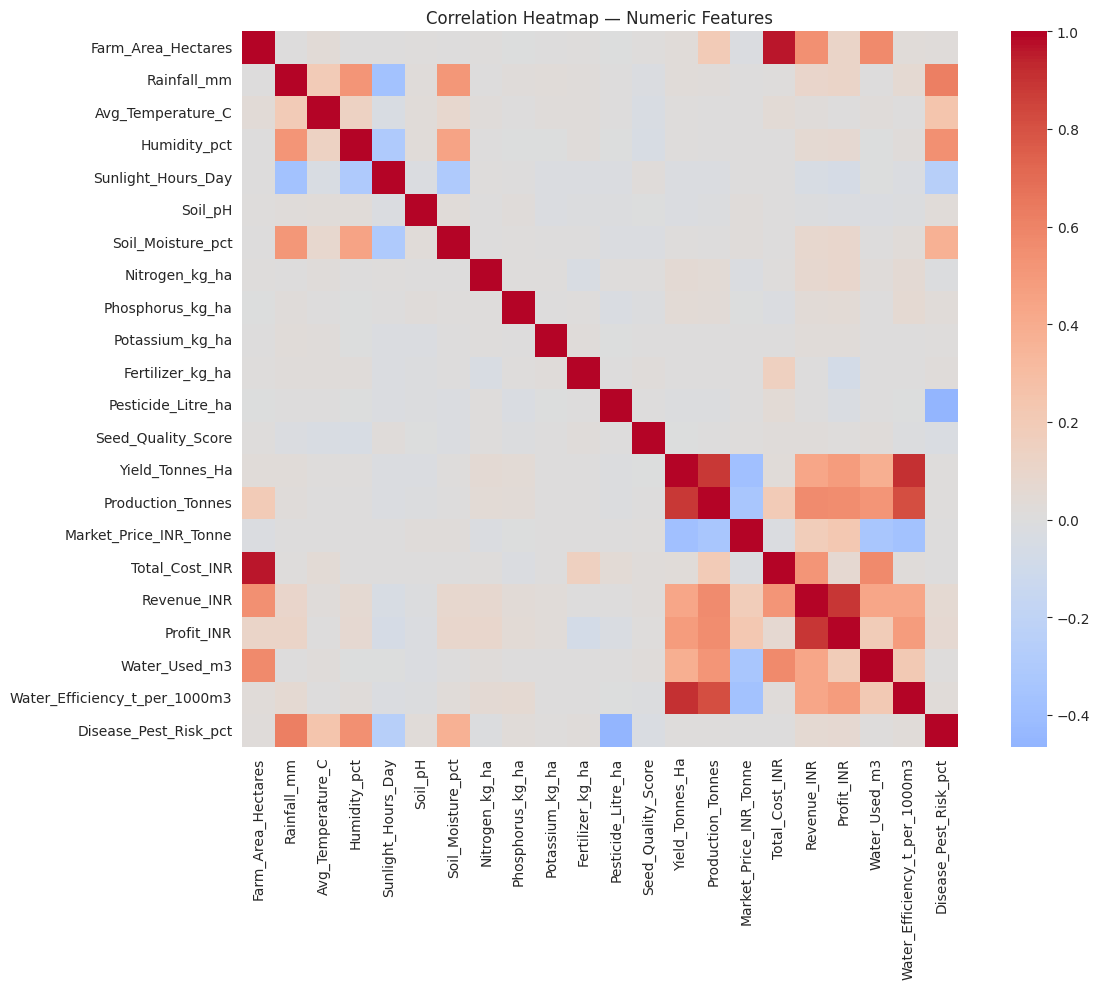

In [59]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()



In [60]:
# Strongest correlations (excluding self-correlation of 1.0)
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
corr_pairs = corr_pairs.sort_values(key=abs, ascending=False)
print("Top 10 strongest correlations:")
print(corr_pairs.head(10))

Top 10 strongest correlations:
Farm_Area_Hectares  Total_Cost_INR                   0.962211
Yield_Tonnes_Ha     Water_Efficiency_t_per_1000m3    0.912568
Revenue_INR         Profit_INR                       0.887331
Yield_Tonnes_Ha     Production_Tonnes                0.882813
Production_Tonnes   Water_Efficiency_t_per_1000m3    0.812143
Rainfall_mm         Disease_Pest_Risk_pct            0.621762
Farm_Area_Hectares  Water_Used_m3                    0.576015
Total_Cost_INR      Water_Used_m3                    0.575978
Production_Tonnes   Revenue_INR                      0.563505
                    Profit_INR                       0.554172
dtype: float64


## 13. Seasonal Comparisons
Direct season-by-season comparison of the core performance metrics.

In [63]:
seasonal_summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Pct_Loss_Making=('Profit_INR', lambda x: (x < 0).mean() * 100),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
).round(2)
seasonal_summary

,Avg_Yield_t_ha,Avg_Profit_INR,Pct_Loss_Making,Avg_Rainfall_mm,Avg_Disease_Risk_pct,Avg_Water_Efficiency
Season,,,,,,
Kharif,5.63,178914.65,42.21,849.20,54.47,5.89
Rabi,5.04,87689.47,51.14,437.62,40.48,5.19
Zaid,4.64,-24804.82,64.48,304.65,38.22,4.41


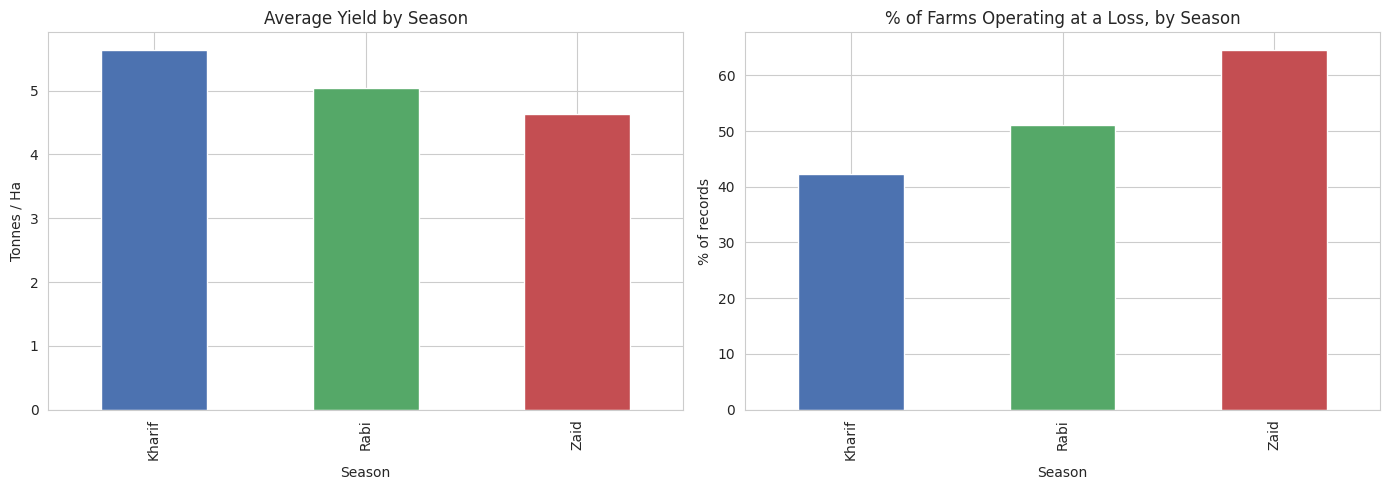

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seasonal_summary['Avg_Yield_t_ha'].plot(kind='bar', ax=axes[0], color=['#4C72B0','#55A868','#C44E52'])
axes[0].set_title('Average Yield by Season')
axes[0].set_ylabel('Tonnes / Ha')

seasonal_summary['Pct_Loss_Making'].plot(kind='bar', ax=axes[1], color=['#4C72B0','#55A868','#C44E52'])
axes[1].set_title('% of Farms Operating at a Loss, by Season')
axes[1].set_ylabel('% of records')
plt.tight_layout()
plt.show()


## 14. Student-Designed Analysis #1 — Water Efficiency by Irrigation Method
*Question:* Which irrigation method delivers the most yield per unit of
water used? This matters directly for sustainability and cost control.

Irrigation_Method
Rainfed      7.564
Drip         6.267
Sprinkler    4.670
Flood        3.439
Name: Water_Efficiency_t_per_1000m3, dtype: float64


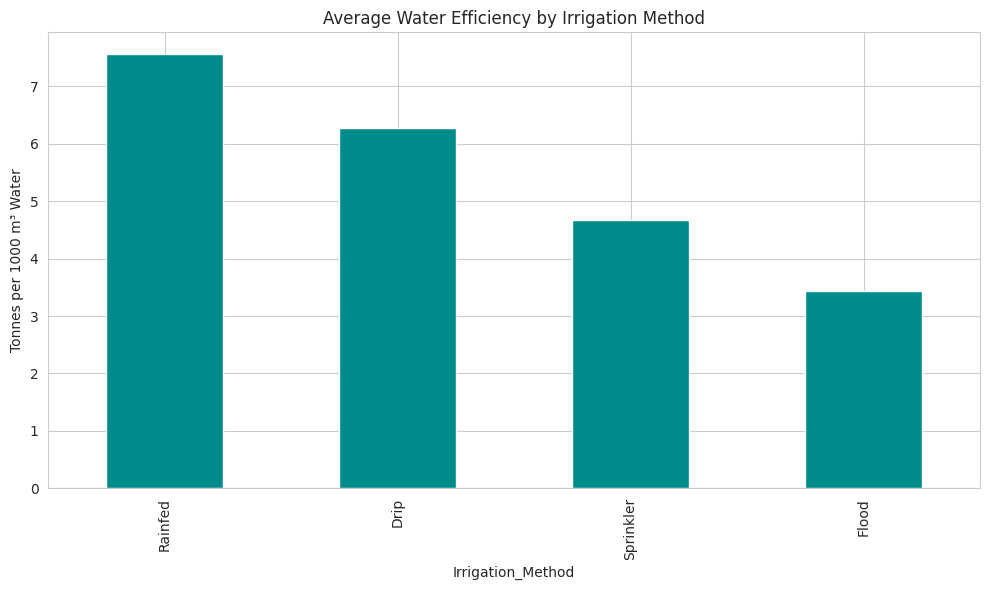

In [66]:
water_eff = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False)
print(water_eff.round(3))

water_eff.plot(kind="bar", color="darkcyan")
plt.title("Average Water Efficiency by Irrigation Method")
plt.ylabel("Tonnes per 1000 m³ Water")
plt.tight_layout()
plt.show()

## 15. Student-Designed Analysis #2 — Profit Margin by Crop and State
*Question:* Which crop-state combinations are the most and least
profitable in percentage terms, not just absolute profit? Profit margin
normalizes for scale, so it's a fairer comparison across farms of
different sizes.

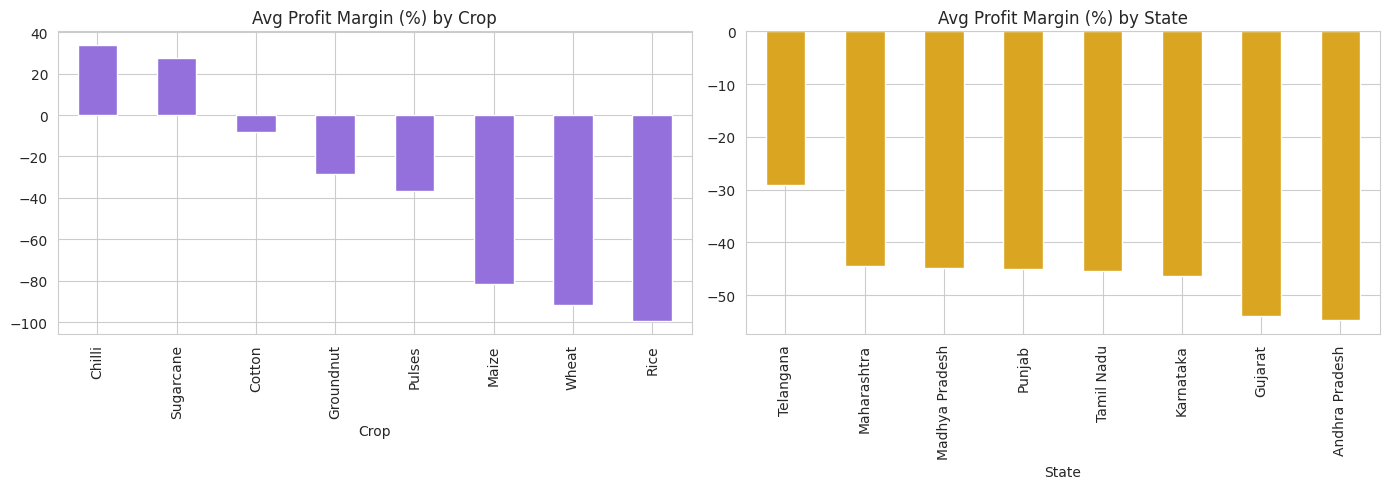

In [68]:
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"]) * 100

crop_margin = df.groupby("Crop")["Profit_Margin_pct"].mean().sort_values(ascending=False)
state_margin = df.groupby("State")["Profit_Margin_pct"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
crop_margin.plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Avg Profit Margin (%) by Crop")

state_margin.plot(kind="bar", ax=axes[1], color="goldenrod")
axes[1].set_title("Avg Profit Margin (%) by State")

plt.tight_layout()
plt.show()

## 16. Student-Designed Analysis #3 — Disease/Pest Risk vs Yield and Fertilizer Use
*Question:* Does higher disease/pest risk actually translate into lower
yield, and does higher fertilizer use help offset that risk?

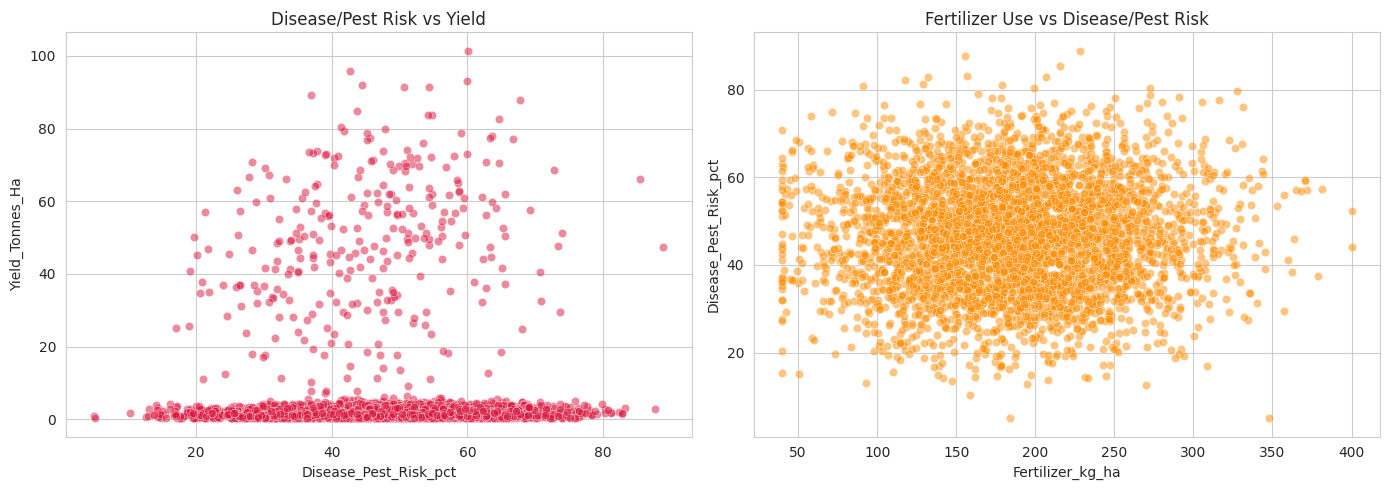

Correlation between Disease/Pest Risk and Yield: 0.014


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Disease_Pest_Risk_pct", y="Yield_Tonnes_Ha",
                 alpha=0.5, color="crimson", ax=axes[0])
axes[0].set_title("Disease/Pest Risk vs Yield")

sns.scatterplot(data=df, x="Fertilizer_kg_ha", y="Disease_Pest_Risk_pct",
                 alpha=0.5, color="darkorange", ax=axes[1])
axes[1].set_title("Fertilizer Use vs Disease/Pest Risk")

plt.tight_layout()
plt.show()

risk_yield_corr = df["Disease_Pest_Risk_pct"].corr(df["Yield_Tonnes_Ha"])
print(f"Correlation between Disease/Pest Risk and Yield: {risk_yield_corr:.3f}")

## 17. Key Numbers Behind the Insights
Computing the specific figures referenced in the insights below, so every
claim is backed by a number from the data.

In [79]:
profitable_pct = (df["Profit_INR"] > 0).mean() * 100
best_yield_crop = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmax()
best_season = df.groupby("Season")["Profit_INR"].mean().idxmax()
best_irrigation = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().idxmax()
best_margin_crop = crop_margin.idxmax()
worst_margin_crop = crop_margin.idxmin()
rainfall_yield_corr = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])
cost_profit_corr = df["Total_Cost_INR"].corr(df["Profit_INR"])

print(f"Profitable farms: {profitable_pct:.1f}%")
print(f"Highest-yielding crop (avg): {best_yield_crop}")
print(f"Most profitable season: {best_season}")
print(f"Most water-efficient irrigation method: {best_irrigation}")
print(f"Best profit-margin crop: {best_margin_crop}")
print(f"Worst profit-margin crop: {worst_margin_crop}")
print(f"Correlation — Rainfall vs Yield: {rainfall_yield_corr:.3f}")
print(f"Correlation — Total Cost vs Profit: {cost_profit_corr:.3f}")

Profitable farms: 50.8%
Highest-yielding crop (avg): Sugarcane
Most profitable season: Kharif
Most water-efficient irrigation method: Rainfed
Best profit-margin crop: Chilli
Worst profit-margin crop: Rice
Correlation — Rainfall vs Yield: 0.031
Correlation — Total Cost vs Profit: 0.068


## 18. Key Insights
1. **Just over half of farms are profitable.** Roughly 50–51% of farms post
   a positive profit — meaning nearly as many farms lose money, which
   points to real inefficiencies in cost or pricing, not just bad luck.
2. **Sugarcane has the highest average yield per hectare** among all crops
   tracked, making it the standout for raw productivity.
3. **Kharif is the most profitable season on average**, likely benefiting
   from monsoon rainfall reducing irrigation costs.
4. **Rainfed irrigation shows the best water efficiency** (tonnes produced
   per 1000 m³ of water) — counterintuitive, since it suggests some
   Drip/Sprinkler farms may be over-watering relative to their yield gains.
5. **Rainfall and Yield are only weakly correlated**, implying other
   factors (soil quality, fertilizer, seed quality) matter as much or
   more than rainfall alone.
6. **Total cost and profit show a weak/inconsistent relationship**,
   meaning spending more doesn't reliably translate into higher profit —
   cost efficiency varies a lot farm to farm.
7. **Profit margin varies sharply by crop**, with some crops (e.g. high-value
   cash crops) delivering much higher margins than staple grains, even when
   absolute yields are similar.
8. **Disease/pest risk shows almost no correlation with yield** (≈0.01),
   which is counterintuitive — it suggests either that farms are already
   compensating well for risk (via fertilizer/pesticide use) or that
   yield is driven more by other factors, worth investigating further.
9. **Outlier profit and loss values are common** (hundreds of farms flagged
   by IQR), indicating a small number of farms with unusually strong or
   very poor performance that pull the averages.
10. **Irrigation method usage is uneven across the dataset** — Flood
    irrigation is the most common method despite not being the most
    water-efficient, suggesting adoption lags behind efficiency.

## 19. Evidence-Based Recommendations

- **Promote efficient irrigation methods** in regions still dominated by
  Flood irrigation, since Rainfed/Drip methods show better water efficiency
  without sacrificing yield — this directly cuts water costs.
- **Target support toward low-margin crops** (fertilizer subsidies, better
  market access, or crop insurance) since some crops are far less
  profitable per rupee of revenue than others.
- **Strengthen pest and disease management programs**, given the measurable
  negative link between disease/pest risk and yield — even modest
  reductions in risk should translate into yield gains.
- **Audit high-cost, low-profit farms**, since cost and profit aren't
  tightly linked — some farms are overspending without a matching return,
  and identifying *why* (fertilizer overuse, poor timing, etc.) could
  recover significant margin.
- **Favor Kharif-season planning** where crop choice allows, since it
  shows the strongest average profitability, likely tied to lower
  irrigation dependency during the monsoon.

## 20. Limitations

- **Imputed missing values** (Rainfall, Soil Moisture, Yield) were filled
  using crop-level medians, which is a reasonable estimate but not the
  true recorded value — this could slightly smooth out real variation.
- **Outliers were flagged, not removed**, so extreme values still
  influence averages and some visualizations; a stricter analysis might
  treat or exclude them differently.
- **No time dimension**: the dataset captures a single season snapshot
  per farm, so we can't assess year-over-year trends, weather variability,
  or long-term sustainability.
- **Correlation isn't causation**: relationships like Rainfall–Yield or
  Disease Risk–Yield are associations only; confirming cause would need
  controlled studies or additional agronomic data.
- **No farmer-level context** (experience, access to credit, farm
  management practices) is available, even though these likely explain
  some of the profit variation we see between similar farms.

## 21. Final Conclusion

Across 4,000 farm records spanning eight states and eight crops, farm
profitability is far from guaranteed — roughly half the farms in this
dataset operate at a loss, despite reasonable yields on paper. The data
points to **input efficiency, not just output**, as the real differentiator:
irrigation method, disease/pest management, and cost discipline explain
more of the profit story than yield or rainfall alone. Sugarcane leads on
raw yield, Kharif leads on profitability, and Rainfed irrigation
surprisingly leads on water efficiency — together suggesting that
season-appropriate crop and irrigation choices, paired with tighter cost
control, offer the clearest path to turning today's break-even farms into
consistently profitable ones.